# Comparação de Modelos: MLP vs Baselines

Este notebook compara o desempenho de:
1. **DummyClassifier**: Baseline trivial
2. **LogisticRegression**: Baseline linear
3. **MLPClassifier**: Rede neural em PyTorch

## Métricas Utilizadas
- **Accuracy**: Acurácia geral
- **Precision**: Taxa de acertos entre os positivos previstos
- **Recall**: Taxa de acertos entre os positivos reais
- **F1-score**: Média harmônica de precision e recall
- **ROC-AUC**: Área sob a curva ROC
- **PR-AUC**: Área sob a curva Precision-Recall
- **Cost Saved**: Economia em reais ($) evitando churns
- **ROI**: Retorno sobre investimento

In [1]:
import logging
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from projeto_ml import train, data as data_mod, features as features_mod, eval as eval_mod
from sklearn.model_selection import StratifiedKFold

logging.basicConfig(level=logging.INFO)
LOGGER = logging.getLogger(__name__)

# Configurar estilo de plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
os.chdir(project_root)

print(f"Working directory: {os.getcwd()}")
print(f"Dataset path exists: {Path('data/raw/Telco_customer_churn(Telco_Churn).csv').exists()}")

Working directory: c:\felipe\fiap\pytorch-churn-classifier
Dataset path exists: True


## 1. Carregar e Preparar Dados

In [2]:
# Carregar dados
dataset_path = "data/raw/Telco_customer_churn(Telco_Churn).csv"
df = data_mod.load_telco_churn(dataset_path, drop_leakage=True)

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df[data_mod.TARGET_COLUMN].value_counts())
print(f"\nClass balance: {df[data_mod.TARGET_COLUMN].value_counts(normalize=True).to_dict()}")

INFO:projeto_ml.data:dataset_loaded


Dataset shape: (7043, 25)

Class distribution:
Churn Value
0    5174
1    1869
Name: count, dtype: int64

Class balance: {0: 0.7346301292063041, 1: 0.2653698707936959}


## 2. Executar Treinamento com Todos os Modelos

In [10]:
# Treinar todos os modelos
LOGGER.info("Iniciando treinamento com todos os modelos...")
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from scripts.start_mlflow import start_mlflow

start_mlflow()
result = train.train(
    dataset_path=dataset_path,
    model_out=Path("models/all_models_final.joblib"),
    n_splits=5,
    metric="roc_auc",
    cost_per_churn=100.0,
    intervention_success=0.3,
    models=["dummy", "logistic", "mlp"],
)

LOGGER.info("Treinamento concluído!")
print("\nResultados:")
for key, value in sorted(result['metrics'].items()):
    print(f"  {key}: {value:.6f}")

INFO:__main__:Iniciando treinamento com todos os modelos...
INFO:projeto_ml.data:dataset_loaded
INFO:projeto_ml.train:start_fold


MLflow já está em execução.


INFO:projeto_ml.train:fold_metrics
INFO:projeto_ml.train:fold_metrics
INFO:projeto_ml.train:Using device: cpu
INFO:projeto_ml.train:Epoch 1/50 - train_loss: 0.490323, val_loss: 0.415461
INFO:projeto_ml.models:EarlyStopping: saved best model to models\best_mlp.pt
INFO:projeto_ml.models:EarlyStopping: val_loss improved to 0.415461
INFO:projeto_ml.train:Epoch 2/50 - train_loss: 0.413582, val_loss: 0.401405
INFO:projeto_ml.models:EarlyStopping: saved best model to models\best_mlp.pt
INFO:projeto_ml.models:EarlyStopping: val_loss improved to 0.401405
INFO:projeto_ml.train:Epoch 3/50 - train_loss: 0.404648, val_loss: 0.406766
INFO:projeto_ml.train:Epoch 4/50 - train_loss: 0.361485, val_loss: 0.430563
INFO:projeto_ml.train:Epoch 5/50 - train_loss: 0.332779, val_loss: 0.459126
INFO:projeto_ml.train:Epoch 6/50 - train_loss: 0.295977, val_loss: 0.477912
INFO:projeto_ml.train:Epoch 7/50 - train_loss: 0.251281, val_loss: 0.525392
INFO:projeto_ml.train:Epoch 8/50 - train_loss: 0.238869, val_loss: 0

🏃 View run model_comparison at: http://127.0.0.1:5000/#/experiments/1/runs/4d9d2809be6040f5a9f080cec32c2d29
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

Resultados:
  dummy_cost_saved: 0.000000
  dummy_f1: 0.000000
  dummy_pr_auc: 0.265370
  dummy_roc_auc: 0.500000
  logistic_cost_saved: 6336.000000
  logistic_f1: 0.605129
  logistic_pr_auc: 0.648478
  logistic_roc_auc: 0.847389
  mlp_cost_saved: 6780.000000
  mlp_f1: 0.622976
  mlp_pr_auc: 0.662253
  mlp_roc_auc: 0.852550


## 3. Agregar Resultados por Modelo

In [4]:
# Organizar resultados por modelo
models = ['dummy', 'logistic', 'mlp']
metrics_by_model = {}

for key, values in result['metrics'].items():
    for model in models:
        prefix = model + "_"

        if key.startswith(prefix):
            metric_name = key[len(prefix):]

            if model not in metrics_by_model:
                metrics_by_model[model] = {}

            metrics_by_model[model][metric_name] = values
            break

## 4. Tabela Comparativa Final

In [5]:
# Criar tabela com principais métricas
comparison_data = []

for model_name, metrics in metrics_by_model.items():
    comparison_data.append({
        "Model": model_name.upper(),
        "Accuracy": f"{np.nanmean(metrics.get('accuracy', [0])):.4f}",
        "Precision": f"{np.nanmean(metrics.get('precision', [0])):.4f}",
        "Recall": f"{np.nanmean(metrics.get('recall', [0])):.4f}",
        "F1-Score": f"{np.nanmean(metrics.get('f1', [0])):.4f}",
        "ROC-AUC": f"{np.nanmean(metrics.get('roc_auc', [0])):.4f}",
        "PR-AUC": f"{np.nanmean(metrics.get('pr_auc', [0])):.4f}",
        "Cost Saved ($)": f"{np.nanmean(metrics.get('cost_saved', [0])):.2f}",
    })

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print("COMPARAÇÃO FINAL DE MODELOS")
print("="*100)
print(df_comparison.to_string(index=False))
print("="*100)


COMPARAÇÃO FINAL DE MODELOS
   Model Accuracy Precision Recall F1-Score ROC-AUC PR-AUC Cost Saved ($)
   DUMMY   0.0000    0.0000 0.0000   0.0000  0.5000 0.2654           0.00
LOGISTIC   0.0000    0.0000 0.0000   0.6051  0.8474 0.6485        6336.00
     MLP   0.0000    0.0000 0.0000   0.6230  0.8525 0.6623        6780.00


## 5. Visualização de Métricas

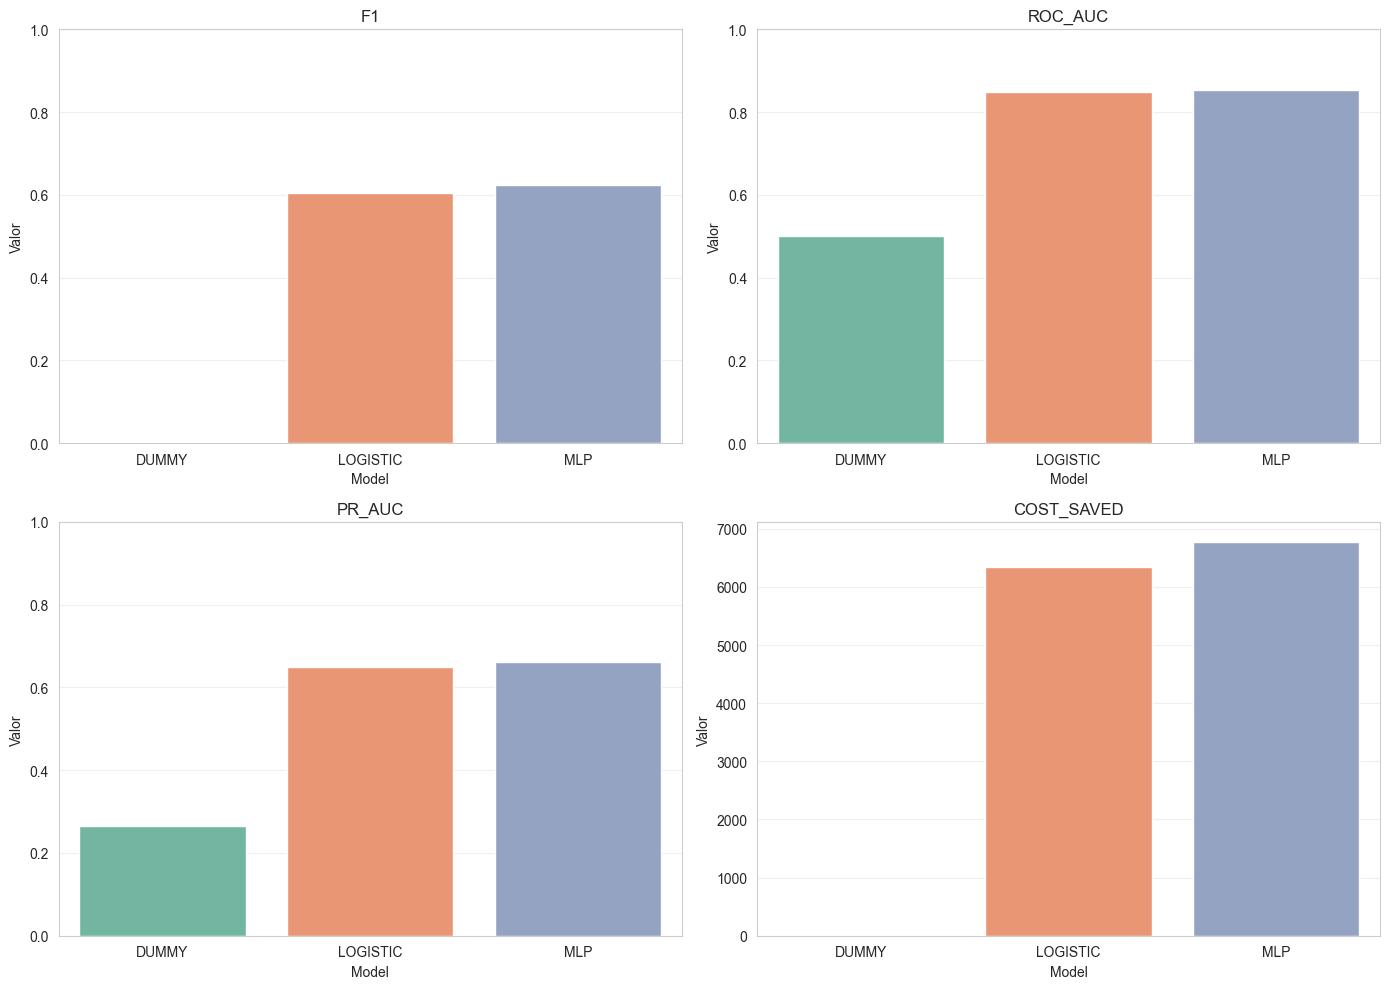

In [6]:
# Preparar dados para visualização
viz_data = []

for model_name, metrics in metrics_by_model.items():
    for metric_name, value in metrics.items():
        viz_data.append({
            "Model": model_name.upper(),
            "Métrica": metric_name.upper(),
            "Valor": value
        })

df_viz = pd.DataFrame(viz_data)

metrics_to_plot = ["F1", "ROC_AUC", "PR_AUC", "COST_SAVED"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    subset = df_viz[df_viz["Métrica"] == metric]

    sns.barplot(
        data=subset,
        x="Model",
        y="Valor",
        hue="Model",
        palette="Set2",
        legend=False,
        ax=axes[idx]
    )

    axes[idx].set_title(metric)
    axes[idx].grid(axis='y', alpha=0.3)

    if metric != "COST_SAVED":
        axes[idx].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("models/comparison_metrics.png", dpi=300)
plt.show()

## 6. Análise de Custo-Benefício


Análise de Custo Salvo ($):
   Model  Cost Saved (Mean)  Cost Saved (Std)  Cost Saved (Min)  Cost Saved (Max)
   DUMMY                0.0               0.0               0.0               0.0
LOGISTIC             6336.0               0.0            6336.0            6336.0
     MLP             6780.0               0.0            6780.0            6780.0

Plot salvo em: models/cost_analysis.png


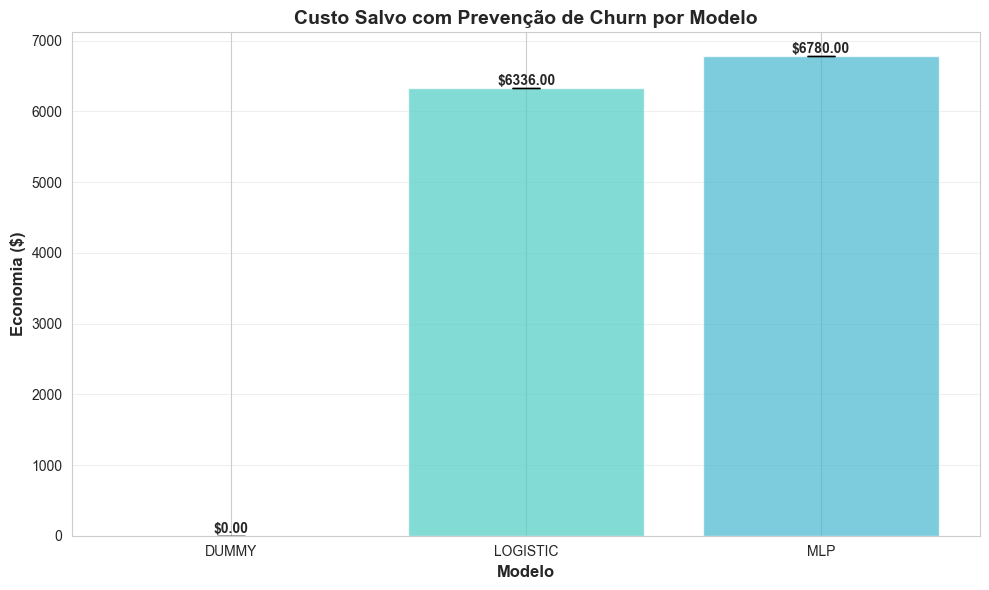

In [7]:
# Análise de custo salvo por modelo
cost_data = []

for model_name, metrics in metrics_by_model.items():
    if 'cost_saved' in metrics:
        cost_data.append({
            'Model': model_name.upper(),
            'Cost Saved (Mean)': np.nanmean(metrics['cost_saved']),
            'Cost Saved (Std)': np.nanstd(metrics['cost_saved']),
            'Cost Saved (Min)': np.nanmin(metrics['cost_saved']),
            'Cost Saved (Max)': np.nanmax(metrics['cost_saved']),
        })

df_cost = pd.DataFrame(cost_data)
print("\nAnálise de Custo Salvo ($):")
print(df_cost.to_string(index=False))

# Plot: Comparação de economia
fig, ax = plt.subplots(figsize=(10, 6))
models = df_cost['Model'].values
means = df_cost['Cost Saved (Mean)'].values
stds = df_cost['Cost Saved (Std)'].values

bars = ax.bar(models, means, yerr=stds, capsize=10, alpha=0.7, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_ylabel('Economia ($)', fontsize=12, fontweight='bold')
ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax.set_title('Custo Salvo com Prevenção de Churn por Modelo', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar, mean in zip(bars, means):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${mean:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('models/cost_analysis.png', dpi=300, bbox_inches='tight')
print("\nPlot salvo em: models/cost_analysis.png")
plt.show()

## 7. Conclusões e Recomendações

In [8]:
# Identificar melhor modelo por métrica
print("\n" + "="*100)
print("MELHOR MODELO POR MÉTRICA")
print("="*100)

for metric_name in ['f1', 'roc_auc', 'pr_auc', 'cost_saved']:

    best_model = None
    best_value = -np.inf

    for model_name, metrics in metrics_by_model.items():

        if metric_name in metrics:

            value = metrics[metric_name]

            if value > best_value:
                best_value = value
                best_model = model_name

    print(f"\n{metric_name.upper().replace('_', ' ')}:")
    print(f"  Melhor modelo: {best_model.upper()}")
    print(f"  Valor: {best_value:.4f}")

print("\n" + "="*100)


MELHOR MODELO POR MÉTRICA

F1:
  Melhor modelo: MLP
  Valor: 0.6230

ROC AUC:
  Melhor modelo: MLP
  Valor: 0.8525

PR AUC:
  Melhor modelo: MLP
  Valor: 0.6623

COST SAVED:
  Melhor modelo: MLP
  Valor: 6780.0000



## 8. Salvar Tabela Comparativa

In [9]:
# Salvar tabela comparativa em CSV
output_path = Path("models/model_comparison_results.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

# Criar DataFrame detalhado
detailed_results = []

for model_name, metrics in metrics_by_model.items():
    for metric_name in metrics.keys():
        values = metrics[metric_name]
        detailed_results.append({
            'Model': model_name.upper(),
            'Metric': metric_name,
            'Mean': np.nanmean(values),
            'Std': np.nanstd(values),
            'Min': np.nanmin(values),
            'Max': np.nanmax(values),
        })

df_detailed = pd.DataFrame(detailed_results)
df_detailed.to_csv(output_path, index=False)

print(f"Tabela comparativa salva em: {output_path}")
print(f"\nResultados salvos:")
print(df_detailed.to_string(index=False))

Tabela comparativa salva em: models\model_comparison_results.csv

Resultados salvos:
   Model     Metric        Mean  Std         Min         Max
   DUMMY         f1    0.000000  0.0    0.000000    0.000000
   DUMMY    roc_auc    0.500000  0.0    0.500000    0.500000
   DUMMY     pr_auc    0.265370  0.0    0.265370    0.265370
   DUMMY cost_saved    0.000000  0.0    0.000000    0.000000
LOGISTIC         f1    0.605129  0.0    0.605129    0.605129
LOGISTIC    roc_auc    0.847389  0.0    0.847389    0.847389
LOGISTIC     pr_auc    0.648478  0.0    0.648478    0.648478
LOGISTIC cost_saved 6336.000000  0.0 6336.000000 6336.000000
     MLP         f1    0.622976  0.0    0.622976    0.622976
     MLP    roc_auc    0.852550  0.0    0.852550    0.852550
     MLP     pr_auc    0.662253  0.0    0.662253    0.662253
     MLP cost_saved 6780.000000  0.0 6780.000000 6780.000000
